# Figure 4 — Entorhinal Cortex Population Coding (Open Field)

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
import os, glob, warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

CI_FAC = 1.96
MAX_N  = 10
TICK_FS = 7

out_dir = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
os.makedirs(out_dir, exist_ok=True)

In [99]:
MIN_BYTES = 100

def _load_assay_csvs(src):
    files = glob.glob(os.path.join(src, '*.csv'))
    valid_files, skipped = [], []
    for f in files:
        size = os.path.getsize(f)
        if size < MIN_BYTES:
            skipped.append((f, size))
        else:
            valid_files.append(f)
    for f, size in skipped:
        print(f'Skipped ({size} byte{"s" if size != 1 else ""}): {os.path.basename(f)}')
    if skipped:
        print(f'  {len(skipped)} file(s) skipped, {len(valid_files)} loading...')
    df = pd.concat(
        [pd.read_csv(f, keep_default_na=False, na_values=['']) for f in valid_files],
        ignore_index=True
    )
    df = df.dropna(how='all')
    df['baseline'] = df['baseline'].replace('pos_speed_hd_hing_lfp', 'pos_speed_hd_lfp')
    df = df[~df['baseline'].str.contains('hing', na=False)]
    if 'n_neurons' in df.columns and 'n_covariate_cells' not in df.columns:
        df = df.rename(columns={'n_neurons': 'n_covariate_cells', 'pR2': 'pR2_cv'})
    return df

print('Loading OF data...')
data_of = _load_assay_csvs('/Users/harryclark/Documents/spatial-manifolds/data/eddie/xgboost_cell_number_assay_of/')
print(f'OF:  {data_of.shape}  baselines: {sorted(data_of["baseline"].dropna().unique())}')


Loading OF data...
OF:  (4558093, 8)  baselines: ['hd', 'lfp', 'null', 'pos', 'pos_hd', 'pos_lfp', 'pos_speed', 'pos_speed_hd', 'pos_speed_hd_lfp', 'pos_speed_lfp', 'speed']


In [100]:
def infer_target_type(cov_set):
    if 'cmGC'  in cov_set: return 'cmGC'
    if 'ncmGC' in cov_set: return 'ncmGC'
    return 'NGS'

def _add_target_broad(df):
    tt = (df.groupby(['mouse', 'day', 'target_cluster_id'])['covariate_type']
            .apply(lambda x: infer_target_type(set(x)))
            .reset_index()
            .rename(columns={'covariate_type': 'target_type'}))
    df = df.merge(tt, on=['mouse', 'day', 'target_cluster_id'], how='left')
    df['target_broad'] = df['target_type'].apply(
        lambda t: 'GC' if t in ('cmGC', 'ncmGC') else 'NGS')
    return df

def sig_star(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return 'ns'

data_of = _add_target_broad(data_of)

cov_col = 'covariate_cell_type'
print('OF target types:', data_of['target_broad'].value_counts().to_dict())
print('OF covariate types:', sorted(data_of[cov_col].dropna().unique()))


OF target types: {'NGS': 4197063, 'GC': 361030}
OF covariate types: ['GC', 'NGS']


## Kinematic baseline models

Each cell's firing rate is predicted by XGBoost regression fitted to kinematic variables recorded in the open field. Cross-validated pseudo-R² (pR²) quantifies how much firing variance is captured. The baselines are additive combinations of:

- **pos** — 2D position
- **speed** — running speed
- **hd** — head direction
- **lfp** — LFP theta index

The **null** model uses no kinematics (intercept only); **pos_speed_hd_lfp** is the most complex. All downstream analyses add population covariate cells on top of these baselines to test whether population activity carries information beyond kinematics.

In [101]:
OF_BASELINE_ORDER = [
    'null',
    'pos', 'speed', 'hd', 'lfp',
    'pos_speed', 'pos_hd', 'pos_lfp',
    'pos_speed_hd', 'pos_speed_lfp',
    'pos_speed_hd_lfp',
]
OF_BASELINE_LABEL = {
    'null':             'Null',
    'pos':              'Pos',
    'speed':            'Speed',
    'hd':               'HD',
    'lfp':              'LFP',
    'pos_speed':        'Pos+Spd',
    'pos_hd':           'Pos+HD',
    'pos_lfp':          'Pos+LFP',
    'pos_speed_hd':     'Pos+Spd+HD',
    'pos_speed_lfp':    'Pos+Spd+LFP',
    'pos_speed_hd_lfp': 'Pos+Spd+HD+LFP',
}

---

## Medial vs Lateral NGS Data

### Scientific question

Grid cells reside in the **medial** entorhinal cortex. Non-grid spatial (NGS) cells span both medial (abs(SC_x) < 3400 µm) and lateral (abs(SC_x) ≥ 3400 µm) entorhinal cortex. This section tests whether medial NGS cells are more tightly coupled to the grid cell network than lateral NGS cells.

**Coupling measure:** Δ pR² = pR²(baseline + *n* NGS cells) − pR²(baseline only, *n* = 0). A larger Δ pR² means NGS population activity explains target cell firing beyond what kinematics alone account for.

### Panels produced

**Line plots (6 combinations):** Δ pR² vs *n* covariate cells (0–10) for each target × covariate location pair:

| Target | Covariate | Question |
|--------|-----------|----------|
| GC | NGS-medial | Do medial NGS cells predict GC firing beyond kinematics? |
| GC | NGS-lateral | Do lateral NGS cells? |
| NGS-medial | NGS-medial | Within-region coupling among medial NGS cells |
| NGS-medial | NGS-lateral | Cross-region: lateral NGS predicting medial NGS |
| NGS-lateral | NGS-medial | Cross-region: medial NGS predicting lateral NGS |
| NGS-lateral | NGS-lateral | Within-region coupling among lateral NGS cells |

Each trace is one kinematic baseline, coloured by complexity (inferno scale).

**Redundancy ratio matrix (3 × 2):** Δ pR²(null) / Δ pR²(complex) at *n* = MAX_N. A ratio of 1 means the population signal is entirely independent of kinematics. A ratio of 2 means half the population signal overlaps with kinematic variance and is redundant. Wilcoxon stars test whether the median ratio differs from 1.

In [102]:
print('Loading medlat NGS OF data...')
data_ml_of = _load_assay_csvs('/Users/harryclark/Documents/spatial-manifolds/data/eddie/xgboost_medlat_ngs_of/')
print(f'OF:  {data_ml_of.shape}')

print('\n=== OF columns ===')
print(list(data_ml_of.columns))
for col in data_ml_of.columns:
    uvals = data_ml_of[col].dropna().unique()
    if len(uvals) <= 30:
        print(f'  {col}: {sorted(uvals)}')


Loading medlat NGS OF data...
OF:  (871750, 8)

=== OF columns ===
['mouse', 'day', 'target_cluster_id', 'target_type', 'baseline', 'n_covariate_cells', 'covariate_location', 'pR2_cv']
  mouse: [np.int64(20), np.int64(21), np.int64(22), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
  day: [np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(37), np.int64(38)]
  target_type: ['NGS', 'NS', 'cmGC', 'ncmGC']
  baseline: ['hd', 'lfp', 'null', 'pos', 'pos_hd', 'pos_lfp', 'pos_speed', 'pos_speed_hd', 'pos_speed_hd_lfp', 'pos_speed_lfp', 'speed']
  n_covariate_cells: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  covariate_location: ['lateral', 'medial']


In [103]:
# ── Merge target cell locations from cell_classifications.csv ─────────────────
# abs(SC_x): lower = more medial (GCs ~3270), higher = more lateral (~3510+)
# Adjust MEDLAT_SC_X_THRESHOLD to split medial vs lateral NGS target cells.

MEDLAT_SC_X_THRESHOLD = 3400   # μm — cells with abs(SC_x) < threshold = medial

cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
cc['target_location'] = cc['SC_x'].abs().apply(
    lambda v: 'medial' if v < MEDLAT_SC_X_THRESHOLD else 'lateral'
)
cc_lut = cc[['mouse', 'day', 'cluster_id', 'target_location']].rename(
    columns={'cluster_id': 'target_cluster_id'}
)
cc_lut['mouse'] = cc_lut['mouse'].astype(int)
cc_lut['day']   = cc_lut['day'].astype(int)

data_ml_of['mouse'] = data_ml_of['mouse'].astype(int)
data_ml_of['day']   = data_ml_of['day'].astype(int)
data_ml_of['target_cluster_id'] = data_ml_of['target_cluster_id'].astype(int)

data_ml_of = data_ml_of.merge(cc_lut, on=['mouse', 'day', 'target_cluster_id'], how='left')

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'Threshold: abs(SC_x) < {MEDLAT_SC_X_THRESHOLD} → medial, else lateral\n')
n_missing = data_ml_of['target_location'].isna().sum()
counts    = data_ml_of.groupby(['target_type', 'target_location']).size().unstack(fill_value=0)
print(f'OF:  {n_missing} rows with no location match')
print(counts)

sc = (data_ml_of[data_ml_of['n_covariate_cells'] == 0]
      .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id'])
      .merge(cc[['mouse', 'day', 'cluster_id', 'SC_x']].rename(columns={'cluster_id': 'target_cluster_id'}),
             on=['mouse', 'day', 'target_cluster_id'], how='left'))
sc['abs_SC_x'] = sc['SC_x'].abs()
print('\nabs(SC_x) by target_type:')
print(sc.groupby('target_type')['abs_SC_x']
        .describe(percentiles=[.25, .5, .75]).round(0).to_string())


Threshold: abs(SC_x) < 3400 → medial, else lateral

OF:  770 rows with no location match
target_location  lateral  medial
target_type                     
NGS               400642  235829
NS                103807   60126
cmGC               14949   32857
ncmGC              15697    7073

abs(SC_x) by target_type:
              count    mean    std     min     25%     50%     75%     max
target_type                                                               
NGS          3425.0  3419.0  265.0  2610.0  3270.0  3510.0  3606.0  3759.0
NS            878.0  3385.0  302.0  2610.0  3207.0  3510.0  3606.0  3759.0
cmGC          240.0  3301.0  185.0  2760.0  3193.0  3270.0  3510.0  3746.0
ncmGC         134.0  3420.0  266.0  2610.0  3285.0  3510.0  3600.0  3757.0


---

## ENT Cells: Baseline pR² and Tuning Score Relationships

Restricted to entorhinal cortex cells (ENT; abs(SC_x) 3000–3800 µm). NGS cells are coloured by their medial–lateral position using the cividis scale (vmin = 3000 µm, vmax = 3800 µm).

**Baseline pR² bar chart:** Mean ± 95% CI kinematic baseline pR² across all baseline models, split by cell type (GC, NGS-medial at 3200 µm, NGS-lateral at 3600 µm).

**Scatter panels (Position / Speed / Head direction / LFP):** Baseline pR² at *n* = 0 vs the tuning score for the matching kinematic variable. Tests whether cells well-tuned to a kinematic feature are better predicted by that feature's model. Spearman *r* shown in each panel.

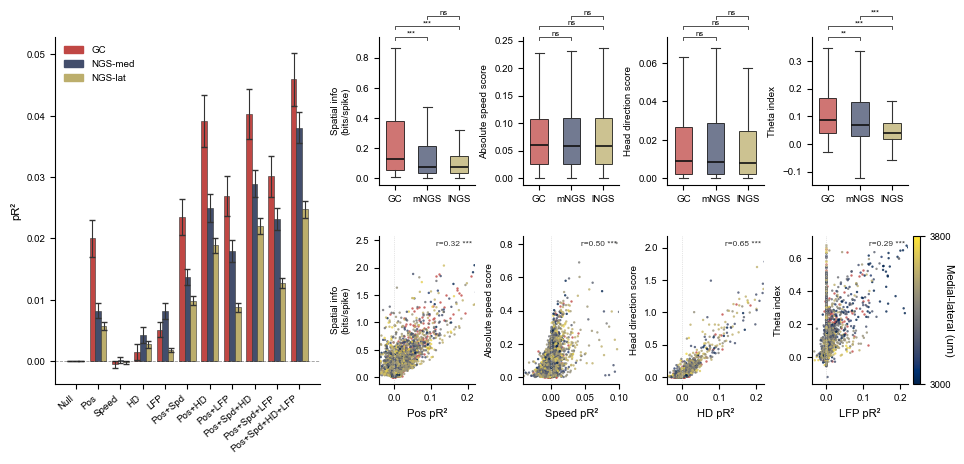

In [104]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

PANEL_DEFS = [
    ('pos',   'spatial_information_score_best', 'Spatial info\n(bits/spike)',  0.22, 'Pos pR²'),
    ('speed', 'speed_score',                    'Absolute speed score',        0.10, 'Speed pR²'),
    ('hd',    'head_direction_score',            'Head direction score',        0.22, 'HD pR²'),
    ('lfp',   'theta_index',                     'Theta index',                0.22, 'LFP pR²'),
]

GC_COL     = '#c04744'
ALPHA      = 0.8
MS         = 3
ngs_cmap   = plt.cm.cividis
ngs_norm   = Normalize(vmin=3000, vmax=3800)
NGSMED_COL = ngs_cmap(ngs_norm(3200))
NGSLAT_COL = ngs_cmap(ngs_norm(3600))
GROUPS     = ['GC', 'mNGS', 'lNGS']
GRP_COLORS = [GC_COL, NGSMED_COL, NGSLAT_COL]

# ── Data ──────────────────────────────────────────────────────────────────────
cc_scores = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
cc_scores = cc_scores.rename(columns={'cluster_id': 'target_cluster_id'})
for col in ['mouse', 'day', 'target_cluster_id']:
    cc_scores[col] = cc_scores[col].astype(int)
cc_scores = cc_scores[cc_scores['brain_region'].str.contains('ENT', na=False)]

score_cols_needed = [sc for _, sc, _, _, _ in PANEL_DEFS]
cc_sub = cc_scores[
    ['mouse', 'day', 'target_cluster_id', 'SC_x'] +
    [c for c in score_cols_needed if c in cc_scores.columns]
].drop_duplicates()

n0_all = (data_of[data_of['n_covariate_cells'] == 0]
              .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id', 'baseline'])
              .copy())
n0_all = n0_all[n0_all['baseline'].isin(OF_BASELINE_ORDER)]
for col in ['mouse', 'day', 'target_cluster_id']:
    n0_all[col] = n0_all[col].astype(int)

merged_all = n0_all.merge(cc_sub, on=['mouse', 'day', 'target_cluster_id'], how='inner')
merged_all['abs_SC_x'] = merged_all['SC_x'].abs()
merged_all['ngs_loc']  = np.where(
    merged_all['abs_SC_x'] < MEDLAT_SC_X_THRESHOLD, 'medial', 'lateral'
)

# Cell-level df for boxplots (one row per cell)
cell_df = merged_all.drop_duplicates(subset=['mouse', 'day', 'target_cluster_id']).copy()
cell_df['group'] = np.select(
    [
        cell_df['target_broad'] == 'GC',
        (cell_df['target_broad'] == 'NGS') & (cell_df['ngs_loc'] == 'medial'),
        (cell_df['target_broad'] == 'NGS') & (cell_df['ngs_loc'] == 'lateral'),
    ],
    GROUPS, default=None,
)
cell_df = cell_df[cell_df['group'].isin(GROUPS)]

# ── p-value bracket helper ─────────────────────────────────────────────────────
def _pstar(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

def _add_brackets(ax, data_list, positions):
    pairs = [(0, 1), (0, 2), (1, 2)]

    pvals = []
    for i, j in pairs:
        a, b = data_list[i], data_list[j]
        _, p = sp_stats.mannwhitneyu(a, b, alternative='two-sided') \
               if len(a) > 1 and len(b) > 1 else (None, np.nan)
        pvals.append(p)

    w_tops, w_bots = [], []
    for vals in data_list:
        if not len(vals):
            w_tops.append(0); w_bots.append(0); continue
        q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
        iqr = q3 - q1
        hi = vals[vals <= q3 + 1.5 * iqr]
        lo = vals[vals >= q1 - 1.5 * iqr]
        w_tops.append(hi.max() if len(hi) else q3)
        w_bots.append(lo.min() if len(lo) else q1)

    w_max = max(w_tops)
    w_min = min(w_bots)
    span  = max(w_max - w_min, 1e-6)

    ax.set_ylim(w_min - span * 0.05, w_max + span * 0.08)

    h_bar = span * 0.025
    step  = span * 0.08

    for k, ((i, j), p) in enumerate(zip(pairs, pvals)):
        if np.isnan(p):
            continue
        y   = w_max + span * 0.06 + step * k
        xi, xj = positions[i], positions[j]
        ax.plot([xi, xi, xj, xj], [y, y + h_bar, y + h_bar, y],
                lw=0.6, c='#333', clip_on=False)
        ax.text((xi + xj) / 2, y + h_bar, _pstar(p),
                ha='center', va='bottom', fontsize=5.5, clip_on=False)

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 4.5))
gs_outer = fig.add_gridspec(1, 2, width_ratios=[0.4, 0.8], wspace=0.15)
ax_bar   = fig.add_subplot(gs_outer[0, 0])
gs_right = gs_outer[0, 1].subgridspec(2, 4, hspace=0.35, wspace=0.5)
box_axs  = [fig.add_subplot(gs_right[0, i]) for i in range(4)]
scat_axs = [fig.add_subplot(gs_right[1, i]) for i in range(4)]

# ── Bar chart ─────────────────────────────────────────────────────────────────
x      = np.arange(len(OF_BASELINE_ORDER))
w      = 0.25
err_kw = dict(elinewidth=0.8, capsize=2, ecolor='#333')

for xi, bl in enumerate(OF_BASELINE_ORDER):
    sub_bl = merged_all[merged_all['baseline'] == bl]
    for filt, xoff, color in [
        (lambda d: d[d['target_broad'] == 'GC'],                                  -w, GC_COL),
        (lambda d: d[(d['target_broad'] == 'NGS') & (d['ngs_loc'] == 'medial')],   0, NGSMED_COL),
        (lambda d: d[(d['target_broad'] == 'NGS') & (d['ngs_loc'] == 'lateral')], +w, NGSLAT_COL),
    ]:
        vals = filt(sub_bl)['pR2_cv'].dropna()
        if not len(vals): continue
        ax_bar.bar(xi + xoff, vals.mean(), yerr=CI_FAC * vals.sem(),
                   width=w, color=color, edgecolor='#333', linewidth=0.4,
                   error_kw=err_kw)

ax_bar.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([OF_BASELINE_LABEL[bl] for bl in OF_BASELINE_ORDER],
                        rotation=40, ha='right', fontsize=TICK_FS)
ax_bar.set_ylabel('pR²', fontsize=8)
ax_bar.tick_params(labelsize=TICK_FS)
ax_bar.spines[['top', 'right']].set_visible(False)
ax_bar.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=GC_COL,    label='GC'),
        plt.Rectangle((0, 0), 1, 1, color=NGSMED_COL, label='NGS-med'),
        plt.Rectangle((0, 0), 1, 1, color=NGSLAT_COL, label='NGS-lat'),
    ],
    fontsize=TICK_FS, frameon=False, loc='upper left',
)

# ── Boxplots (top-right, no column titles) ────────────────────────────────────
for ax, (bl, score_col, score_label, _, _x) in zip(box_axs, PANEL_DEFS):
    score_data = []
    for grp in GROUPS:
        vals = cell_df[cell_df['group'] == grp][score_col].dropna().values
        if score_col == 'speed_score':
            vals = np.abs(vals)
        score_data.append(vals)

    bp = ax.boxplot(score_data, positions=range(3), widths=0.55,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='#111', lw=1.2),
                    whiskerprops=dict(lw=0.8, color='#333'),
                    capprops=dict(lw=0.8, color='#333'),
                    boxprops=dict(lw=0.7))
    for patch, col in zip(bp['boxes'], GRP_COLORS):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    _add_brackets(ax, score_data, list(range(3)))

    ax.set_xticks(range(3))
    ax.set_xticklabels(GROUPS, fontsize=TICK_FS)
    ax.set_ylabel(score_label, fontsize=7)
    ax.tick_params(labelsize=TICK_FS)
    ax.spines[['top', 'right']].set_visible(False)

# ── Scatters (bottom-right) ───────────────────────────────────────────────────
for ax, (bl, score_col, score_label, xlim, scat_xlabel) in zip(scat_axs, PANEL_DEFS):
    sub = merged_all[merged_all['baseline'] == bl].copy()
    if score_col == 'speed_score':
        sub[score_col] = sub[score_col].abs()
    sub = sub[['target_broad', 'abs_SC_x', score_col, 'pR2_cv']].dropna()

    gc_pts  = sub[sub['target_broad'] == 'GC']
    ngs_pts = sub[sub['target_broad'] == 'NGS']

    ax.scatter(gc_pts['pR2_cv'], gc_pts[score_col],
               s=MS, color=GC_COL, alpha=ALPHA, linewidths=0)
    if len(ngs_pts):
        ax.scatter(ngs_pts['pR2_cv'], ngs_pts[score_col],
                   s=MS, c=ngs_cmap(ngs_norm(ngs_pts['abs_SC_x'].values)),
                   alpha=ALPHA, linewidths=0)

    if len(sub) > 5:
        r, p = sp_stats.spearmanr(sub['pR2_cv'], sub[score_col], nan_policy='omit')
        star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(0.97, 0.97, f'r={r:.2f} {star}',
                ha='right', va='top', transform=ax.transAxes,
                fontsize=6, color='#333')

    ax.axvline(0, color='#ccc', lw=0.5, ls=':')
    ax.set_xlim(left=-0.04, right=xlim)
    ax.set_xlabel(scat_xlabel, fontsize=8)
    ax.set_ylabel(score_label, fontsize=7)
    ax.tick_params(labelsize=TICK_FS)
    ax.spines[['top', 'right']].set_visible(False)

# ── Colorbar ──────────────────────────────────────────────────────────────────
fig.canvas.draw()
pos = scat_axs[-1].get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.005, pos.y0, 0.006, pos.height])
cb = fig.colorbar(ScalarMappable(norm=ngs_norm, cmap=ngs_cmap), cax=cbar_ax)
cb.set_ticks([3000, 3800]); cb.set_ticklabels(['3000', '3800'])
cb.ax.set_ylabel('Medial-lateral (um)', fontsize=8, labelpad=2, rotation=270)
cb.ax.tick_params(labelsize=TICK_FS)

fig.savefig(os.path.join(out_dir, 'Figure4_pR2_vs_tuning_scores_OF_v2.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

---

## ENT Cell Type Proportions: Medial vs Lateral

Fraction of GC and NG cells recorded in medial vs lateral entorhinal cortex (threshold: abs(SC_x) = 3400 µm). Lateral and medial groups are subsampled to equal *n* before computing proportions, removing sampling bias. The four bars show GC-medial, NG-medial | GC-lateral, NG-lateral.

n per region after subsampling: 1971  (orig medial=1971, lateral=3916)
GC:  medial=77.2%  lateral=22.8%  (n=505)
NG:  medial=46.0%  lateral=54.0%  (n=3437)


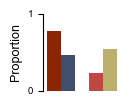

In [105]:
from matplotlib.ticker import PercentFormatter

MEDLAT_THRESHOLD = 3400
np.random.seed(42)

cc_prop = pd.read_csv(
    '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv'
)
cc_prop['abs_SC_x'] = cc_prop['SC_x'].abs()
cc_prop = cc_prop[
    cc_prop['cell_type'].isin(['GC', 'NG']) &
    cc_prop['brain_region'].str.contains('ENT', na=False)
].copy()
cc_prop['region'] = np.where(cc_prop['abs_SC_x'] < MEDLAT_THRESHOLD, 'Medial', 'Lateral')

# Subsample larger region to match smaller
n_med  = (cc_prop['region'] == 'Medial').sum()
n_lat  = (cc_prop['region'] == 'Lateral').sum()
n_each = min(n_med, n_lat)
med_idx = cc_prop[cc_prop['region'] == 'Medial'].index
lat_idx = cc_prop[cc_prop['region'] == 'Lateral'].sample(n=n_each, random_state=42).index
cc_sub  = cc_prop.loc[med_idx.union(lat_idx)]

print(f'n per region after subsampling: {n_each}  (orig medial={n_med}, lateral={n_lat})')

gc = cc_sub[cc_sub['cell_type'] == 'GC']
ng = cc_sub[cc_sub['cell_type'] == 'NG']

gc_p_med = (gc['region'] == 'Medial').mean()
gc_p_lat = 1 - gc_p_med
ng_p_med = (ng['region'] == 'Medial').mean()
ng_p_lat = 1 - ng_p_med

print(f'GC:  medial={gc_p_med:.1%}  lateral={gc_p_lat:.1%}  (n={len(gc)})')
print(f'NG:  medial={ng_p_med:.1%}  lateral={ng_p_lat:.1%}  (n={len(ng)})')

# Layout: [GC med | NG med] dashed gap [GC lat | NG lat]
# bars touch within each pair; gap of 0.6 between pairs
W = 0.6
xs      = [0, W, W*2 + 0.6, W*3 + 0.6]
heights = [gc_p_med, ng_p_med, gc_p_lat, ng_p_lat]
colors  = ['#8B2500', NGSMED_COL, '#c04744', NGSLAT_COL]

fig, ax = plt.subplots(figsize=(1,1))

for x, h, c in zip(xs, heights, colors):
    ax.bar(x, h, width=W, color=c, align='edge')

ax.set_xticks([])
ax.set_ylabel('Proportion', fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0, 1])
ax.tick_params(labelsize=TICK_FS)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

fig.savefig(os.path.join(out_dir, 'Figure4_GC_NG_medlat_proportion.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()


---

## Functional Coupling Graph: GC ↔ mNGS ↔ lNGS

Directed graph estimating kinematic-independent functional coupling among three populations: grid cells (GC), medial NGS (mNGS, abs(SC_x) < 3400 µm) and lateral NGS (lNGS).

**Coupling measure:** Δ pR²(complex baseline) at *n* = MAX_N — the gain in pR² when covariate cells are added on top of the most complex kinematic baseline. Because kinematics are already partialled out, this gain reflects shared variance that is independent of movement.

**Edge direction:** covariate → target (arrow points to the predicted population). Edge width and opacity encode coupling strength. **Self-loops** show within-group coupling.

**Data sources:**
- GC → X edges: `xgboost_cell_number_assay_of` (GC cells as covariates; target identity from `cell_classifications.csv`)
- NGS → X edges: `xgboost_medlat_ngs_of` (medial or lateral NGS cells as covariates)

Node positions (abs_SC_x, SC_y):
  GC    : abs_SC_x=3301.0 um, SC_y=2977.5
  mNGS  : abs_SC_x=3134.4 um, SC_y=2964.9
  lNGS  : abs_SC_x=3584.7 um, SC_y=3413.4
Coupling (delta pR2 complex):
  GC     -> GC    : 0.02444
  GC     -> mNGS  : 0.01994
  GC     -> lNGS  : 0.00945
  mNGS   -> GC    : 0.01818
  mNGS   -> mNGS  : 0.02446
  mNGS   -> lNGS  : 0.00831
  lNGS   -> GC    : 0.00092
  lNGS   -> mNGS  : 0.00387
  lNGS   -> lNGS  : 0.01354


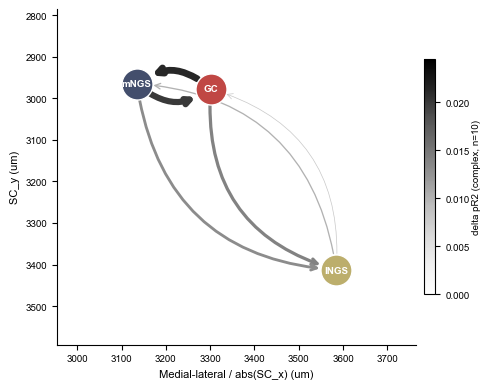

In [106]:
GC_TYPES  = ['cmGC', 'ncmGC']  # target_type values that are grid cells
NGS_TYPES = ['NGS']            # target_type values that are non-grid spatial

complex_bl = OF_BASELINE_ORDER[-1]

# ── Average anatomical positions per group ────────────────────────────────────
cc_pos = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
cc_pos['abs_SC_x'] = cc_pos['SC_x'].abs()
cc_pos['group'] = None
cc_pos.loc[cc_pos['cell_type'] == 'GC', 'group'] = 'GC'
cc_pos.loc[(cc_pos['cell_type'] == 'NG') & (cc_pos['abs_SC_x'] < MEDLAT_SC_X_THRESHOLD), 'group'] = 'mNGS'
cc_pos.loc[(cc_pos['cell_type'] == 'NG') & (cc_pos['abs_SC_x'] >= MEDLAT_SC_X_THRESHOLD), 'group'] = 'lNGS'

pos_mean = cc_pos[cc_pos['group'].notna()].groupby('group')[['abs_SC_x', 'SC_y']].mean()
node_xy  = {g: (pos_mean.loc[g, 'abs_SC_x'], pos_mean.loc[g, 'SC_y']) for g in ['GC', 'mNGS', 'lNGS']}
print('Node positions (abs_SC_x, SC_y):')
for g, (x, y) in node_xy.items():
    print(f'  {g:6s}: abs_SC_x={x:.1f} um, SC_y={y:.1f}')

# ── Coupling values (mean only, no CI) ───────────────────────────────────────
cc_clf = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
cc_clf['target_location'] = cc_clf['SC_x'].abs().apply(
    lambda v: 'medial' if v < MEDLAT_SC_X_THRESHOLD else 'lateral'
)
cc_type_lut = (cc_clf[['mouse', 'day', 'cluster_id', 'cell_type', 'target_location']]
               .rename(columns={'cluster_id': 'target_cluster_id'}))
cc_type_lut['mouse'] = cc_type_lut['mouse'].astype(int)
cc_type_lut['day']   = cc_type_lut['day'].astype(int)

data_of_loc = data_of.copy()
for _col in ['mouse', 'day', 'target_cluster_id']:
    data_of_loc[_col] = data_of_loc[_col].astype(int)
data_of_loc = data_of_loc.merge(cc_type_lut, on=['mouse', 'day', 'target_cluster_id'], how='left')

def _dc_of(cell_type_val, tgt_loc, cov_types):
    mask = (
        (data_of_loc['cell_type'] == cell_type_val) &
        (data_of_loc[cov_col].isin(cov_types)) &
        (data_of_loc['baseline'] == complex_bl)
    )
    if tgt_loc is not None:
        mask &= data_of_loc['target_location'] == tgt_loc
    sub  = data_of_loc[mask]
    n0   = sub[sub['n_covariate_cells'] == 0]['pR2_cv'].mean()
    nmax = sub[sub['n_covariate_cells'] == MAX_N]['pR2_cv'].mean()
    return max(nmax - n0, 0)

def _dc_ml(tgt_types, tgt_loc, cov_loc):
    mask = (
        data_ml_of['target_type'].isin(tgt_types) &
        (data_ml_of['covariate_location'] == cov_loc) &
        (data_ml_of['baseline'] == complex_bl)
    )
    if tgt_loc is not None and 'target_location' in data_ml_of.columns:
        mask &= data_ml_of['target_location'] == tgt_loc
    sub  = data_ml_of[mask]
    n0   = sub[sub['n_covariate_cells'] == 0]['pR2_cv'].mean()
    nmax = sub[sub['n_covariate_cells'] == MAX_N]['pR2_cv'].mean()
    return max(nmax - n0, 0)

coupling = {
    ('GC',   'GC'):   _dc_of('GC', None,      ['GC']),
    ('GC',   'mNGS'): _dc_of('NG', 'medial',  ['GC']),
    ('GC',   'lNGS'): _dc_of('NG', 'lateral', ['GC']),
    ('mNGS', 'GC'):   _dc_ml(GC_TYPES,  None,      'medial'),
    ('mNGS', 'mNGS'): _dc_ml(NGS_TYPES, 'medial',  'medial'),
    ('mNGS', 'lNGS'): _dc_ml(NGS_TYPES, 'lateral', 'medial'),
    ('lNGS', 'GC'):   _dc_ml(GC_TYPES,  None,      'lateral'),
    ('lNGS', 'mNGS'): _dc_ml(NGS_TYPES, 'medial',  'lateral'),
    ('lNGS', 'lNGS'): _dc_ml(NGS_TYPES, 'lateral', 'lateral'),
}
print('Coupling (delta pR2 complex):')
for (src, tgt), v in coupling.items():
    print(f'  {src:6s} -> {tgt:6s}: {v:.5f}')

# ── Graph in anatomical coordinates ──────────────────────────────────────────
node_col = {'GC': GC_COL, 'mNGS': NGSMED_COL, 'lNGS': NGSLAT_COL}
NODE_MS   = 500
NODE_R_PT = 12
LW_MAX    = 6

valid_vals = {k: v for k, v in coupling.items() if v > 0 and not np.isnan(v)}
max_c = max(valid_vals.values()) if valid_vals else 1.0
from matplotlib.colors import Normalize as CNorm
from matplotlib.cm import ScalarMappable
edge_norm = CNorm(vmin=0, vmax=max_c)
sm = ScalarMappable(cmap=plt.cm.Greys, norm=edge_norm)
sm.set_array([])

all_x = [xy[0] for xy in node_xy.values()]
all_y = [xy[1] for xy in node_xy.values()]
x_pad = (max(all_x) - min(all_x)) * 0.4 or 50
y_pad = (max(all_y) - min(all_y)) * 0.4 or 50

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_xlim(min(all_x) - x_pad, max(all_x) + x_pad)
ax.set_ylim(min(all_y) - y_pad, max(all_y) + y_pad)
ax.set_xlabel('Medial-lateral / abs(SC_x) (um)', fontsize=8)
ax.set_ylabel('SC_y (um)', fontsize=8)
ax.tick_params(labelsize=TICK_FS)
ax.spines[['top', 'right']].set_visible(False)

x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
y_range = ax.get_ylim()[1] - ax.get_ylim()[0]

# Positive rad arcs one way, negative arcs the other — bidirectional pairs have opposite signs
EDGE_RAD = {
    ('GC',   'mNGS'): +0.4, ('mNGS', 'GC'):   +0.4,
    ('GC',   'lNGS'): +0.4, ('lNGS', 'GC'):   +0.4,
    ('mNGS', 'lNGS'): +0.4, ('lNGS', 'mNGS'): +0.4,
}

cx = np.mean([p[0] for p in node_xy.values()])
cy = np.mean([p[1] for p in node_xy.values()])

def _self_loop_offsets(p):
    dx, dy = p[0] - cx, p[1] - cy
    d = np.sqrt((dx / x_range)**2 + (dy / y_range)**2) or 1
    ox = dx / d * x_range * 0.08
    oy = dy / d * y_range * 0.08
    px = -dy / d * x_range * 0.15
    py =  dx / d * y_range * 0.15
    return (p[0]+ox+px, p[1]+oy+py), (p[0]+ox-px, p[1]+oy-py)

for (src, tgt), val in coupling.items():
    if not (val > 0) or np.isnan(val):
        continue
    lw    = max(0.5, LW_MAX * val / max_c)
    alpha = float(np.clip(0.35 + 0.65 * val / max_c, 0, 1))
    alpha = 1
    color = plt.cm.Greys(0.3 + 0.7 * edge_norm(val))
    p1 = node_xy[src]
    p2 = node_xy[tgt]

    if src == tgt:
        _end, _start = _self_loop_offsets(p1)
        ax.annotate('', xy=_end, xytext=_start,
                    arrowprops=dict(
                        arrowstyle='->', color=color, lw=lw, alpha=alpha,
                        connectionstyle='arc3,rad=1.2',
                        shrinkA=0, shrinkB=0,
                    ))
    else:
        rad = EDGE_RAD.get((src, tgt), 0.4)
        ax.annotate('', xy=p2, xytext=p1,
                    arrowprops=dict(
                        arrowstyle='->', color=color, lw=lw, alpha=alpha,
                        connectionstyle=f'arc3,rad={rad}',
                        shrinkA=NODE_R_PT, shrinkB=NODE_R_PT,
                    ))

# Draw nodes on top of arrows
for name, (x, y) in node_xy.items():
    ax.scatter(x, y, s=NODE_MS, color=node_col[name], zorder=5, edgecolors='w', linewidths=1)
    ax.text(x, y, name, ha='center', va='center',
            fontsize=7, color='w', fontweight='bold', zorder=6)

# Colorbar
cb = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02, aspect=20, shrink=0.7)
cb.set_label(f'delta pR2 (complex, n={MAX_N})', fontsize=7, labelpad=2)
cb.ax.tick_params(labelsize=TICK_FS)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(os.path.join(out_dir, 'Figure4_coupling_graph_OF.pdf'), bbox_inches='tight', dpi=300)
plt.show()


---

## Representative Rate Map Reconstructions

For each target cell type (GC, mNGS, lNGS) one example cell is selected from
the already-loaded assay dataframes (`data_of`, `data_ml_of`).  A 3 × 5 figure
shows, for each target:

| Column | Description |
|--------|-------------|
| **True** | Observed rate map |
| **Kin** | XGBoost fit to position + speed + HD + LFP (kinematic baseline, no population covariates) |
| **+10 GCs** | Kinematic baseline + 10 grid-cell spike trains as covariates |
| **+10 mNGS** | Kinematic baseline + 10 medial NGS spike trains |
| **+10 lNGS** | Kinematic baseline + 10 lateral NGS spike trains |

Covariate cells come from the same recording session as the target; GC/NG
classification and medial–lateral split use `cell_classifications.csv`.


In [107]:
# ── Config: session and target cell IDs ──────────────────────────────────────
SESSION_MOUSE = 25
SESSION_DAY   = 25

# Set a cluster ID to override auto-selection, or leave as None
TARGET_GC_ID   = None
TARGET_MNGS_ID = None
TARGET_LNGS_ID = None

complex_bl = OF_BASELINE_ORDER[-1]  # 'pos_speed_hd_lfp'

_s_of = (data_of['mouse'] == SESSION_MOUSE) & (data_of['day'] == SESSION_DAY)
_s_ml = (data_ml_of['mouse'] == SESSION_MOUSE) & (data_ml_of['day'] == SESSION_DAY)

# GCs must be classified as grid cells in both OF sessions
_gc_both = set(
    cc[(cc['cell_type'] == 'GC') & (cc['classified_by'] == 'both')]
    ['cluster_id'].astype(int)
)

if TARGET_GC_ID is None:
    _c = data_of[
        _s_of & data_of['target_type'].isin(GC_TYPES) &
        data_of['target_cluster_id'].astype(int).isin(_gc_both) &
        (data_of['baseline'] == complex_bl) &
        (data_of['covariate_cell_type'] == 'GC') &
        (data_of['n_covariate_cells'] == MAX_N)
    ].sort_values('pR2_cv', ascending=False)
    TARGET_GC_ID = int(_c.iloc[0].target_cluster_id)

if TARGET_MNGS_ID is None:
    _c = data_ml_of[
        _s_ml & (data_ml_of['target_type'] == 'NGS') &
        (data_ml_of['target_location'] == 'medial') &
        (data_ml_of['baseline'] == complex_bl) &
        (data_ml_of['n_covariate_cells'] == MAX_N)
    ].sort_values('pR2_cv', ascending=False)
    TARGET_MNGS_ID = int(_c.iloc[0].target_cluster_id)

if TARGET_LNGS_ID is None:
    _c = data_ml_of[
        _s_ml & (data_ml_of['target_type'] == 'NGS') &
        (data_ml_of['target_location'] == 'lateral') &
        (data_ml_of['baseline'] == complex_bl) &
        (data_ml_of['n_covariate_cells'] == MAX_N)
    ].sort_values('pR2_cv', ascending=False)
    TARGET_LNGS_ID = int(_c.iloc[0].target_cluster_id)

EXAMPLES = [
    dict(label='GC',   mouse=SESSION_MOUSE, day=SESSION_DAY, cluster_id=TARGET_GC_ID),
    dict(label='mNGS', mouse=SESSION_MOUSE, day=SESSION_DAY, cluster_id=TARGET_MNGS_ID),
    dict(label='lNGS', mouse=SESSION_MOUSE, day=SESSION_DAY, cluster_id=TARGET_LNGS_ID),
]
print(f'Session: M{SESSION_MOUSE} D{SESSION_DAY}')
for ex in EXAMPLES:
    print(f"  {ex['label']:5s}: cluster {ex['cluster_id']}")


Session: M25 D25
  GC   : cluster 83
  mNGS : cluster 127
  lNGS : cluster 222


In [108]:
# ── Load session, build covariate pools, run XGBoost for each target ─────────
import sys, os
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import pynapple as nap
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde as _scipy_kde
from spatial_manifolds.detect_grids import compute_of_tcs, get_theta_trace, time_bs
from spatial_manifolds.mlencoding import MLencoding
from spatial_manifolds.predictive_grid import compute_travel_projected
import matplotlib.gridspec as gridspec

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
N_BINS_2D   = 40
SIGMA_2D    = 2.0
N_COV       = MAX_N   # 10 cells per covariate pool
N_HD_BINS   = 36

def _smooth_nan(arr, sigma=SIGMA_2D):
    mask = np.isnan(arr)
    filled = arr.copy(); filled[mask] = 0.0
    s = gaussian_filter(filled.astype(float), sigma=sigma)
    w = gaussian_filter((~mask).astype(float), sigma=sigma)
    with np.errstate(invalid='ignore'):
        return np.where(w > 0.05, s / w, np.nan)

def _make_rate_map(pred, px, py, n_bins=N_BINS_2D):
    xe = np.linspace(np.nanpercentile(px, 1), np.nanpercentile(px, 99), n_bins + 1)
    ye = np.linspace(np.nanpercentile(py, 1), np.nanpercentile(py, 99), n_bins + 1)
    spk, _, _ = np.histogram2d(px, py, bins=[xe, ye], weights=np.clip(pred, 0, None))
    occ, _, _ = np.histogram2d(px, py, bins=[xe, ye])
    with np.errstate(invalid='ignore', divide='ignore'):
        return _smooth_nan(np.where(occ > 2, spk / occ, np.nan))

def _hd_tuning(pred, hd_vals, n_bins=N_HD_BINS):
    # mean rate per HD bin; hd_vals in radians [0, 2pi]
    hd_norm = hd_vals % (2 * np.pi)
    edges   = np.linspace(0, 2 * np.pi, n_bins + 1)
    spk, _  = np.histogram(hd_norm, bins=edges, weights=np.clip(pred, 0, None))
    occ, _  = np.histogram(hd_norm, bins=edges)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(occ > 0, spk / occ, 0.0), edges

def _get_cov_ids(cc_df, mouse, day, cell_type_label, location,
                 tcs_time, exclude_ids, threshold=MEDLAT_SC_X_THRESHOLD, n=N_COV):
    sub = cc_df[(cc_df['mouse'] == mouse) & (cc_df['day'] == day)].copy()
    if cell_type_label == 'GC':
        sub = sub[(sub['cell_type'] == 'GC') & (sub['classified_by'] == 'both')]
    else:
        sub = sub[sub['cell_type'] == 'NG']
        sub = (sub[sub['SC_x'].abs() < threshold] if location == 'medial'
               else sub[sub['SC_x'].abs() >= threshold])
    return [int(c) for c in sub['cluster_id'].values
            if c not in exclude_ids and c in tcs_time][:n]

# ── Load session ──────────────────────────────────────────────────────────────
mouse, day = SESSION_MOUSE, SESSION_DAY
print(f'Loading M{mouse} D{day}...')
tcs_raw, tcs_time, beh_OF, clusters_OF, ep = compute_of_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=False,
    fill_nans_from_neighbors=True, source_path=SOURCE_PATH
)
last_t = clusters_OF[clusters_OF.index[0]].count(
    bin_size=time_bs, time_units='ms').index[-1]
ep2   = nap.IntervalSet(start=0, end=last_t, time_units='s')
_ref_id = next(iter(tcs_time))
T_ref   = len(np.array(tcs_time[_ref_id]))

def _bin(sig):
    a = np.array(sig.bin_average(bin_size=time_bs, time_units='ms', ep=ep2))[:T_ref]
    return pd.Series(a).ffill().bfill().to_numpy()

pos_x = _bin(beh_OF['P_x'])   # raw (unshifted) — used for trajectory plots
pos_y = _bin(beh_OF['P_y'])
speed = _bin(beh_OF['S'])
hd    = _bin(beh_OF['H'])
T_ref = len(pos_x)

try:
    _theta_id = next(c for c in (ex['cluster_id'] for ex in EXAMPLES) if c in tcs_time)
    theta = np.array(get_theta_trace(
        mouse, day, _theta_id, time_bs=50, resample_bs=time_bs,
        session_type='OF1', source_path=SOURCE_PATH
    ))
    theta = (theta[:T_ref] if len(theta) >= T_ref
             else np.pad(theta, (0, T_ref - len(theta))))
except Exception as e:
    print(f'Theta unavailable ({e}) — zeros.')
    theta = np.zeros(T_ref)

# ── Optimal position shift ────────────────────────────────────────────────────
try:
    _brain_locs = pd.read_csv(SOURCE_PATH + 'all_cluster_brain_locations_chris.csv')
    _fms = (f'{SOURCE_PATH}M{mouse}/D{day:02d}/OF1/tuning_scores/'
            'shifted_spatial_information_manual_smooth.parquet')
    _fns = (f'{SOURCE_PATH}M{mouse}/D{day:02d}/OF1/tuning_scores/'
            'shifted_spatial_information.parquet')
    _df_si     = pd.read_parquet(_fms if os.path.exists(_fms) else _fns)
    _score_col = ('spatial_information' if 'spatial_information' in _df_si.columns
                  else [c for c in _df_si.columns
                        if c not in ('cluster_id','travel','sig','brain_region')][0])
    _travel_at_max = []
    for _cid in _df_si[_df_si['travel'] == 0]['cluster_id'].values:
        _br = _brain_locs[(_brain_locs['mouse'] == mouse) &
                          (_brain_locs['day'] == day) &
                          (_brain_locs['cluster_id'] == _cid)]
        if _br.empty: continue
        if not any(r in _br['brain_region'].iloc[0] for r in ['ENT','PAR','PRE']): continue
        _cdf = _df_si[_df_si['cluster_id'] == _cid]
        _sc  = np.array(_cdf[_score_col])
        _tr  = np.array(_cdf['travel'])
        if len(_sc) == 0 or np.all(np.isnan(_sc)): continue
        _travel_at_max.append(_tr[np.nanargmax(_sc)])
    if len(_travel_at_max) > 3:
        _kde = _scipy_kde(_travel_at_max, bw_method=0.3)
        _xv  = np.linspace(-50, 50, 1000)
        optimal_shift = float(_xv[np.argmax(_kde(_xv))])
        if optimal_shift < -30: optimal_shift = 0.0
    else:
        optimal_shift = 0.0
    print(f'Optimal shift: {optimal_shift:.2f} cm ({len(_travel_at_max)} cells)')
except Exception as e:
    print(f'Optimal shift unavailable ({e}) — using 0.')
    optimal_shift = 0.0

# Shifted position for rate maps and XGBoost features
if optimal_shift != 0.0:
    # compute_travel_projected needs a pynapple TsdFrame with .times()
    _px = np.array(beh_OF['P_x'])
    _py = np.array(beh_OF['P_y'])
    _t  = np.array(beh_OF['P_x'].times())
    _pos_tsd = nap.TsdFrame(t=_t, d=np.stack([_px, _py], axis=1),
                            columns=['P_x', 'P_y'])
    _beh_lag = compute_travel_projected(['P_x', 'P_y'],
                                         np.stack([_px, _py], axis=1),
                                         _pos_tsd, optimal_shift)
    pos_x_rm = _bin(_beh_lag['P_x'])
    pos_y_rm = _bin(_beh_lag['P_y'])
else:
    pos_x_rm, pos_y_rm = pos_x.copy(), pos_y.copy()

kin = np.column_stack([pos_x_rm, pos_y_rm, speed, hd, theta])

cc_df = pd.read_csv(
    '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
cc_df['mouse'] = cc_df['mouse'].astype(int)
cc_df['day']   = cc_df['day'].astype(int)

# ── Covariate pools ───────────────────────────────────────────────────────────
exclude = [ex['cluster_id'] for ex in EXAMPLES]
cov_ids = {
    'GC':   _get_cov_ids(cc_df, mouse, day, 'GC', None,      tcs_time, exclude),
    'mNGS': _get_cov_ids(cc_df, mouse, day, 'NG', 'medial',  tcs_time, exclude),
    'lNGS': _get_cov_ids(cc_df, mouse, day, 'NG', 'lateral', tcs_time, exclude),
}
for k, v in cov_ids.items():
    print(f'  {k}: {len(v)} covariate cells')

def _cov_mat(ids):
    return (np.vstack([np.array(tcs_time[c])[:T_ref] for c in ids]).T
            if ids else None)

cov_mats = {k: _cov_mat(v) for k, v in cov_ids.items()}

# Individual rate maps per covariate cell — use shifted position
cov_ratemaps = {
    k: [_make_rate_map(np.array(tcs_time[c])[:T_ref], pos_x_rm, pos_y_rm)
        for c in ids]
    for k, ids in cov_ids.items()
}

# ── XGBoost models ────────────────────────────────────────────────────────────
xgb = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                 window=time_bs, n_filters=5, max_time=1000)

COV_CONDITIONS = [
    ('kin',  kin),
    ('gc',   cov_mats['GC']),
    ('mngs', cov_mats['mNGS']),
    ('lngs', cov_mats['lNGS']),
]

results = {}
for ex in EXAMPLES:
    tid, label = ex['cluster_id'], ex['label']
    if tid not in tcs_time:
        print(f'WARNING: {label} cluster {tid} not found — skipping')
        continue
    y = np.array(tcs_time[tid])[:T_ref]
    print(f'\n{label} (cluster {tid})')
    results[tid] = {
        'label': label, 'y': y,
        'true':  {'Y_hat': y, 'pR2': np.nan,
                  'rm':    _make_rate_map(y, pos_x_rm, pos_y_rm),
                  'hd_tc': _hd_tuning(y, hd)},
    }
    for cname, X in COV_CONDITIONS:
        if X is None:
            print(f'  {cname}: no cells — skipped')
            results[tid][cname] = None
            continue
        Y_hat, pR2_folds = xgb.fit_cv(X, y, verbose=0, continuous_folds=True)
        Y_hat = np.array(Y_hat)
        pR2   = float(np.nanmean(pR2_folds))
        results[tid][cname] = {
            'Y_hat': Y_hat, 'pR2': pR2,
            'rm':    _make_rate_map(Y_hat, pos_x_rm, pos_y_rm),
            'hd_tc': _hd_tuning(Y_hat, hd),
        }
        print(f'  {cname:6s}  pR2 = {pR2:.4f}')

print('\nDone.')

Loading M25 D25...
Theta unavailable (File /Users/harryclark/Downloads/COHORT12/LFP/M25/D25/OF1/sub-M25_ses-D25_typ-OF1_lfp.npz does not exist) — zeros.
Optimal shift: 5.76 cm (113 cells)
  GC: 10 covariate cells
  mNGS: 10 covariate cells
  lNGS: 10 covariate cells

GC (cluster 83)
  kin     pR2 = 0.0426
  gc      pR2 = 0.1977
  mngs    pR2 = 0.0863
  lngs    pR2 = -0.0039

mNGS (cluster 127)
  kin     pR2 = 0.2775
  gc      pR2 = 0.0747
  mngs    pR2 = 0.1555
  lngs    pR2 = 0.0365

lNGS (cluster 222)
  kin     pR2 = 0.0806
  gc      pR2 = 0.0250
  mngs    pR2 = 0.0305
  lngs    pR2 = 0.0127

Done.


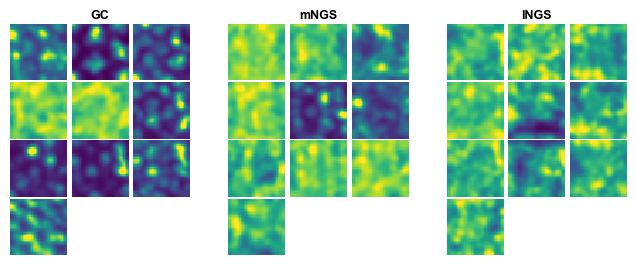

Saved ratemap_covariate_cells.pdf


In [119]:
# ── Plot 1: Covariate cell rate maps ─────────────────────────────────────────
COV_GROUPS     = ['GC', 'mNGS', 'lNGS']
GRID_R, GRID_C = 4, 3

fig1  = plt.figure(figsize=(8, 3))
outer = gridspec.GridSpec(
    1, 5, figure=fig1,
    width_ratios=[GRID_C, 0.2, GRID_C, 0.2, GRID_C], wspace=0.1
)

for gi, gname in enumerate(COV_GROUPS):
    oc    = gi * 2
    inner = gridspec.GridSpecFromSubplotSpec(
        GRID_R, GRID_C, subplot_spec=outer[oc], wspace=0.03, hspace=0.03)
    cells = cov_ratemaps.get(gname, [])
    for ci in range(GRID_R * GRID_C):
        r, c = divmod(ci, GRID_C)
        ax   = fig1.add_subplot(inner[r, c])
        if ci < len(cells):
            rm   = cells[ci]
            vmax = max(np.nanpercentile(rm, 99), 1e-6)
            ax.imshow(rm.T, origin='lower', aspect='equal', cmap='viridis',
                      vmin=0, vmax=vmax, interpolation='none')
            for sp in ax.spines.values(): sp.set_visible(False)
        else:
            ax.set_visible(False)
        ax.set_xticks([]); ax.set_yticks([])
        if ci == 1:
            ax.set_title(gname, fontsize=9, pad=4, fontweight='bold')

plt.savefig(out_dir + 'ratemap_covariate_cells.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved ratemap_covariate_cells.pdf')

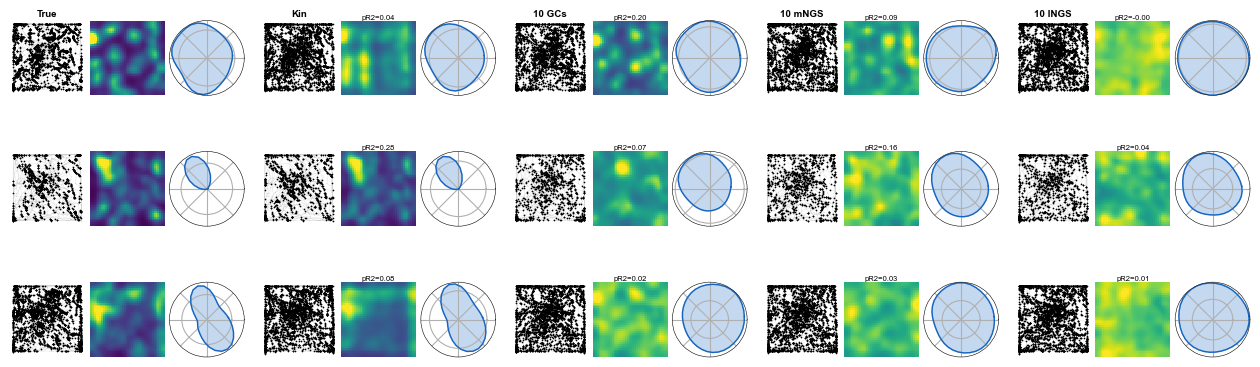

Saved ratemap_target_comparison.pdf


In [110]:
# ── Plot 2: Target cell comparison — 3 rows x 19 columns ────────────────────
from scipy.ndimage import gaussian_filter1d

np.random.seed(42)

COND_DEFS = [
    ('True',    'true',  0),
    ('Kin',     'kin',   4),
    ('10 GCs',  'gc',    8),
    ('10 mNGS', 'mngs', 12),
    ('10 lNGS', 'lngs', 16),
]
SPACER_W = 0.1
wr = []
for _i in range(5):
    wr += [1, 1, 1]
    if _i < 4: wr += [SPACER_W]

hd_bin_w   = 2 * np.pi / N_HD_BINS
hd_centers = np.arange(N_HD_BINS) * hd_bin_w + hd_bin_w / 2

def _smooth_hd(tc, sigma=2):
    # circular Gaussian smooth then close the loop for plotting
    padded = np.concatenate([tc, tc, tc])
    smooth = gaussian_filter1d(padded.astype(float), sigma=sigma)[N_HD_BINS:2*N_HD_BINS]
    return np.append(smooth, smooth[0]), np.append(hd_centers, hd_centers[0])

fig2 = plt.figure(figsize=(16, 5.0))
gs2  = gridspec.GridSpec(3, 19, figure=fig2,
                         width_ratios=wr, wspace=0.08, hspace=0.06)

for row_i, ex in enumerate(EXAMPLES):
    tid = ex['cluster_id']
    if tid not in results:
        continue
    res_all = results[tid]
    y       = res_all['y']

    for ctitle, ckey, c0 in COND_DEFS:
        res = res_all.get(ckey)
        if res is None:
            continue
        Y_hat          = res['Y_hat']
        c_tr, c_rm, c_hd = c0, c0 + 1, c0 + 2

        # trajectory + spikes
        ax_tr = fig2.add_subplot(gs2[row_i, c_tr])
        ax_tr.plot(pos_x, pos_y, color='#d0d0d0', lw=0.2, zorder=1)
        if ckey == 'true':
            sp = y > 0.5
        else:
            sp = np.random.poisson(np.clip(Y_hat, 0, None)) > 0
        ax_tr.scatter(pos_x[sp], pos_y[sp], s=1.5, c='k',
                      linewidths=0, zorder=2)
        ax_tr.set_aspect('equal'); ax_tr.set_xticks([]); ax_tr.set_yticks([])
        ax_tr.axis('off')
        if row_i == 0:
            ax_tr.set_title(ctitle, fontsize=7, pad=3, fontweight='bold')
        if c0 == 0:
            ax_tr.set_ylabel(ex['label'], fontsize=8, labelpad=3)
            ax_tr.yaxis.set_label_coords(-0.05, 0.5)

        # rate map — per-panel 0 to 99th pct
        ax_rm = fig2.add_subplot(gs2[row_i, c_rm])
        rm    = res['rm']
        vmax  = max(np.nanpercentile(rm, 99), 1e-6)
        ax_rm.imshow(rm.T, origin='lower', aspect='equal', cmap='viridis',
                     vmin=0, vmax=vmax, interpolation='none')
        if not np.isnan(res['pR2']):
            ax_rm.set_title(f"pR2={res['pR2']:.2f}", fontsize=5.5, pad=1)
        ax_rm.set_xticks([]); ax_rm.set_yticks([])
        ax_rm.axis('off')

        # HD tuning — smoothed polar line
        ax_hd = fig2.add_subplot(gs2[row_i, c_hd], projection='polar')
        tc, _ = res['hd_tc']
        tc_smooth, th_plot = _smooth_hd(tc)
        ax_hd.plot(th_plot, tc_smooth, color='#1565c0', lw=1.0)
        ax_hd.fill(th_plot, tc_smooth, alpha=0.25, color='#1565c0')
        ax_hd.set_ylim(0, None)
        ax_hd.set_xticklabels([]); ax_hd.set_yticklabels([])
        ax_hd.tick_params(pad=0, length=0)
        ax_hd.spines['polar'].set_linewidth(0.4)

plt.savefig(out_dir + 'ratemap_target_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved ratemap_target_comparison.pdf')

In [111]:
TICK_FS = 6

# ── Merge cell_type + target_location into data_of ────────────────────────────
_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc['target_location'] = _cc['SC_x'].abs().apply(
    lambda v: 'medial' if v < MEDLAT_SC_X_THRESHOLD else 'lateral'
)
_lut = (_cc[['mouse', 'day', 'cluster_id', 'cell_type', 'target_location']]
        .rename(columns={'cluster_id': 'target_cluster_id'})
        .astype({'mouse': int, 'day': int, 'target_cluster_id': int}))

_dof = data_of.copy()
for c in ['mouse', 'day', 'target_cluster_id']:
    _dof[c] = _dof[c].astype(int)
_dof = _dof.merge(_lut, on=['mouse', 'day', 'target_cluster_id'], how='left')

_dml = data_ml_of.copy()

print('_dof shape:', _dof.shape)
print('_dml shape:', _dml.shape)
print('cell_type values:', _dof['cell_type'].dropna().unique())
print('target_location values:', _dof['target_location'].dropna().unique())

_dof shape: (4558093, 12)
_dml shape: (871750, 9)
cell_type values: ['NG' 'GC' 'Other']
target_location values: ['medial' 'lateral']


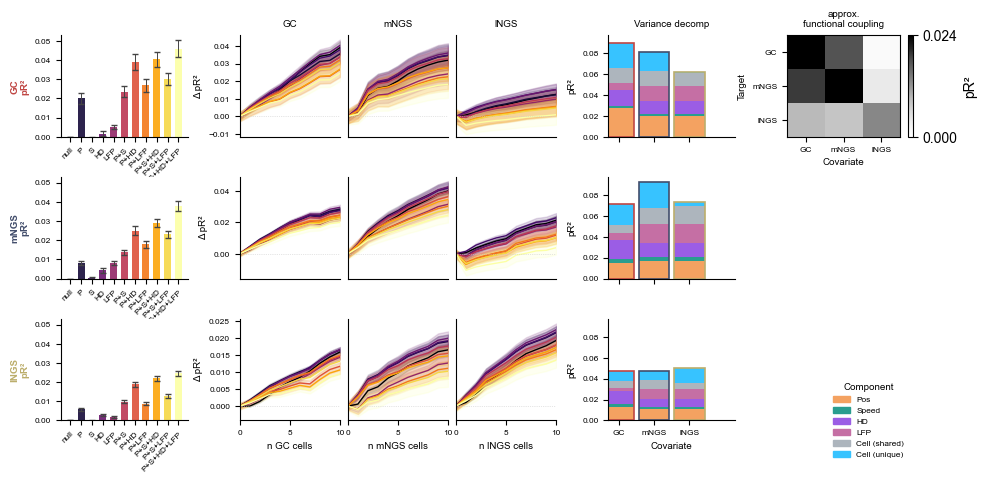

In [112]:
import statsmodels.formula.api as smf
import matplotlib.cm as mpl_cm
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import scipy.stats as sp_stats

# ─── Flags ────────────────────────────────────────────────────────────────────
SHOW_PVALS = False

# ─── Shared constants ─────────────────────────────────────────────────────────
GC_COL       = '#c04744'
ngs_cmap     = plt.cm.cividis
ngs_norm     = Normalize(vmin=3000, vmax=3800)
NGSMED_COL   = ngs_cmap(ngs_norm(3200))
NGSLAT_COL   = ngs_cmap(ngs_norm(3600))
GROUPS       = ['GC', 'mNGS', 'lNGS']
GRP_COLORS_D = [GC_COL, NGSMED_COL, NGSLAT_COL]

BASELINE_SETS = {
    'null':             frozenset(),
    'pos':              frozenset({'pos'}),
    'speed':            frozenset({'speed'}),
    'hd':               frozenset({'hd'}),
    'lfp':              frozenset({'lfp'}),
    'pos_speed':        frozenset({'pos', 'speed'}),
    'pos_hd':           frozenset({'pos', 'hd'}),
    'pos_lfp':          frozenset({'pos', 'lfp'}),
    'pos_speed_hd':     frozenset({'pos', 'speed', 'hd'}),
    'pos_speed_lfp':    frozenset({'pos', 'speed', 'lfp'}),
    'pos_speed_hd_lfp': frozenset({'pos', 'speed', 'hd', 'lfp'}),
}
SET_TO_BL    = {v: k for k, v in BASELINE_SETS.items()}
VAR_COLORS   = {'pos': '#f4a261', 'speed': '#2a9d8f', 'hd': '#9b5de5', 'lfp': '#c56fa4'}
C_SHARED_COL = '#adb5bd'
C_UNIQUE_COL = '#37c3ff'
VARIABLES    = ['pos', 'speed', 'hd', 'lfp']
VAR_LABELS   = {'pos': 'Pos', 'speed': 'Speed', 'hd': 'HD', 'lfp': 'LFP'}
COMP_ORDER   = VARIABLES + ['C_shared', 'C_unique']
COMP_COLORS  = {**VAR_COLORS, 'C_shared': C_SHARED_COL, 'C_unique': C_UNIQUE_COL}
COMP_LABELS  = {**VAR_LABELS, 'C_shared': 'Cell (shared)', 'C_unique': 'Cell (unique)'}
KEY_COLS     = ['mouse', 'day', 'target_cluster_id']

BL_SHORT_LABEL = {
    'null':             'null',
    'pos':              'P',
    'speed':            'S',
    'hd':               'HD',
    'lfp':              'LFP',
    'pos_speed':        'P+S',
    'pos_hd':           'P+HD',
    'pos_lfp':          'P+LFP',
    'pos_speed_hd':     'P+S+HD',
    'pos_speed_lfp':    'P+S+LFP',
    'pos_speed_hd_lfp': 'P+S+HD+LFP',
}

bl_cmap = mpl_cm.inferno
bl_norm = Normalize(vmin=0, vmax=len(OF_BASELINE_ORDER) - 1)

# ─── Baseline data helpers ────────────────────────────────────────────────────
def _bl_mean_sem(tgt_grp, bl):
    sub = merged_all[merged_all['baseline'] == bl]
    if tgt_grp == 'GC':
        sub = sub[sub['target_broad'] == 'GC']
    elif tgt_grp == 'mNGS':
        sub = sub[(sub['target_broad'] == 'NGS') & (sub['ngs_loc'] == 'medial')]
    else:
        sub = sub[(sub['target_broad'] == 'NGS') & (sub['ngs_loc'] == 'lateral')]
    vals = sub['pR2_cv'].dropna()
    return (float(vals.mean()), float(CI_FAC * vals.sem())) if len(vals) else (np.nan, 0)

# ─── Variance decomp helpers ──────────────────────────────────────────────────
def _routes(var):
    out = []
    for bl_name, bl_set in BASELINE_SETS.items():
        if var not in bl_set:
            with_set = bl_set | {var}
            if with_set in SET_TO_BL:
                out.append((bl_name, SET_TO_BL[with_set], len(bl_set)))
    return out

VAR_ROUTES = {v: _routes(v) for v in VARIABLES}

def _sub_df(tgt_grp, cov_grp, bl, n):
    if cov_grp == 'GC':
        sub = _dof[
            (_dof[cov_col].isin(['GC'])) &
            (_dof['baseline'] == bl) &
            (_dof['n_covariate_cells'] == n)
        ].copy()
        if tgt_grp == 'GC':
            sub = sub[sub['cell_type'] == 'GC']
        elif tgt_grp == 'mNGS':
            sub = sub[(sub['cell_type'] == 'NG') & (sub['target_location'] == 'medial')]
        else:
            sub = sub[(sub['cell_type'] == 'NG') & (sub['target_location'] == 'lateral')]
    else:
        cov_loc = 'medial' if cov_grp == 'mNGS' else 'lateral'
        sub = _dml[
            (_dml['covariate_location'] == cov_loc) &
            (_dml['baseline'] == bl) &
            (_dml['n_covariate_cells'] == n)
        ].copy()
        if tgt_grp == 'GC':
            sub = sub[sub['target_type'].isin(GC_TYPES)]
        else:
            sub = sub[sub['target_type'].isin(NGS_TYPES)]
            tgt_loc = 'medial' if tgt_grp == 'mNGS' else 'lateral'
            if 'target_location' in sub.columns:
                sub = sub[sub['target_location'] == tgt_loc]
    return sub[KEY_COLS + ['pR2_cv']].dropna()

def _comp_df(tgt_grp, cov_grp, comp):
    if comp in VARIABLES:
        per_cell = {}
        for bl_s, bl_w, _ in VAR_ROUTES[comp]:
            df_s = _sub_df(tgt_grp, cov_grp, bl_s, 0)
            df_w = _sub_df(tgt_grp, cov_grp, bl_w, 0)
            m = df_s.merge(df_w, on=KEY_COLS, suffixes=('_s', '_w'))
            for _, row in m.iterrows():
                k = (row.mouse, row.day, row.target_cluster_id)
                per_cell.setdefault(k, []).append(row.pR2_cv_w - row.pR2_cv_s)
        rows = [{'mouse': k[0], 'day': k[1], 'target_cluster_id': k[2],
                 'value': float(np.mean(v))}
                for k, v in per_cell.items()]
        return pd.DataFrame(rows) if rows else pd.DataFrame(columns=KEY_COLS + ['value'])
    elif comp == 'C_unique':
        df0 = _sub_df(tgt_grp, cov_grp, 'pos_speed_hd_lfp', 0)
        dfN = _sub_df(tgt_grp, cov_grp, 'pos_speed_hd_lfp', MAX_N)
        m = df0.merge(dfN, on=KEY_COLS, suffixes=('_0', '_N')).copy()
        m['value'] = np.maximum(m['pR2_cv_N'] - m['pR2_cv_0'], 0)
        return m[KEY_COLS + ['value']].reset_index(drop=True)
    elif comp == 'C_shared':
        df_nl0 = _sub_df(tgt_grp, cov_grp, 'null', 0)
        df_nlN = _sub_df(tgt_grp, cov_grp, 'null', MAX_N)
        df_cx0 = _sub_df(tgt_grp, cov_grp, 'pos_speed_hd_lfp', 0)
        df_cxN = _sub_df(tgt_grp, cov_grp, 'pos_speed_hd_lfp', MAX_N)
        m_nl = df_nl0.merge(df_nlN, on=KEY_COLS, suffixes=('_0', '_N'))
        m_cx = df_cx0.merge(df_cxN, on=KEY_COLS, suffixes=('_0', '_N'))
        m = m_nl.merge(m_cx, on=KEY_COLS, suffixes=('_nl', '_cx')).copy()
        c_tot  = np.maximum(m['pR2_cv_N_nl'] - m['pR2_cv_0_nl'], 0)
        c_uniq = np.maximum(m['pR2_cv_N_cx'] - m['pR2_cv_0_cx'], 0)
        m['value'] = np.maximum(c_tot - c_uniq, 0)
        return m[KEY_COLS + ['value']].reset_index(drop=True)
    return pd.DataFrame(columns=KEY_COLS + ['value'])

def _lmm_pval(df_a, df_b):
    try:
        da = df_a[KEY_COLS + ['value']].copy(); da['grp'] = 0
        db = df_b[KEY_COLS + ['value']].copy(); db['grp'] = 1
        df_all = pd.concat([da, db], ignore_index=True).dropna(subset=['value'])
        df_all['mouse'] = df_all['mouse'].astype(str)
        if len(df_all) < 6 or df_all['mouse'].nunique() < 2:
            _, p = sp_stats.ttest_ind(da['value'].dropna(), db['value'].dropna())
            return float(p)
        result = smf.mixedlm('value ~ grp', df_all, groups=df_all['mouse']).fit(
            reml=False, disp=False)
        return float(result.pvalues.get('grp', 1.0))
    except Exception:
        return 1.0

def _pr2(tgt_grp, cov_grp, bl, n):
    v = _sub_df(tgt_grp, cov_grp, bl, n)['pR2_cv']
    return float(v.mean()) if len(v) else np.nan

def _pstar(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

def _get_curves(tgt_grp, cov_grp):
    out = {}
    for bl in OF_BASELINE_ORDER:
        if cov_grp == 'GC':
            sub = _dof[(_dof[cov_col].isin(['GC'])) & (_dof['baseline'] == bl)].copy()
            if tgt_grp == 'GC':
                sub = sub[sub['cell_type'] == 'GC']
            elif tgt_grp == 'mNGS':
                sub = sub[(sub['cell_type'] == 'NG') & (sub['target_location'] == 'medial')]
            else:
                sub = sub[(sub['cell_type'] == 'NG') & (sub['target_location'] == 'lateral')]
        else:
            cov_loc = 'medial' if cov_grp == 'mNGS' else 'lateral'
            sub = _dml[(_dml['covariate_location'] == cov_loc) & (_dml['baseline'] == bl)].copy()
            if tgt_grp == 'GC':
                sub = sub[sub['target_type'].isin(GC_TYPES)]
            else:
                sub = sub[sub['target_type'].isin(NGS_TYPES)]
                tgt_loc = 'medial' if tgt_grp == 'mNGS' else 'lateral'
                if 'target_location' in sub.columns:
                    sub = sub[sub['target_location'] == tgt_loc]
        n0_mean = sub[sub['n_covariate_cells'] == 0]['pR2_cv'].mean()
        rows = []
        for n, grp in sub.groupby('n_covariate_cells'):
            vals = grp['pR2_cv'].dropna()
            if len(vals):
                rows.append({'n': n, 'mean': vals.mean() - n0_mean, 'ci': CI_FAC * vals.sem()})
        if rows:
            out[bl] = pd.DataFrame(rows).sort_values('n')
    return out

# ─── Pre-compute variance decomp ──────────────────────────────────────────────
results = {}
for tgt in GROUPS:
    for cov in GROUPS:
        d = {}
        for var in VARIABLES:
            marginals = []
            for bl_s, bl_w, _ in VAR_ROUTES[var]:
                v_s = _pr2(tgt, cov, bl_s, 0)
                v_w = _pr2(tgt, cov, bl_w, 0)
                if not np.isnan(v_s) and not np.isnan(v_w):
                    marginals.append(v_w - v_s)
            d[var] = dict(mean=np.mean(marginals) if marginals else 0)
        cx_n0   = _pr2(tgt, cov, 'pos_speed_hd_lfp', 0)
        cx_nmax = _pr2(tgt, cov, 'pos_speed_hd_lfp', MAX_N)
        nl_n0   = _pr2(tgt, cov, 'null', 0)
        nl_nmax = _pr2(tgt, cov, 'null', MAX_N)
        c_unique = max(cx_nmax - cx_n0, 0) if not np.isnan(cx_nmax - cx_n0) else 0
        c_total  = max(nl_nmax - nl_n0,  0) if not np.isnan(nl_nmax - nl_n0)  else 0
        d['C_unique'] = dict(mean=c_unique)
        d['C_shared'] = dict(mean=max(c_total - c_unique, 0))
        results[(tgt, cov)] = d

global_max = max(
    sum(max(results[(t, c)][comp]['mean'], 0) for comp in COMP_ORDER)
    for t in GROUPS for c in GROUPS
)

if SHOW_PVALS:
    print('Pre-computing component DataFrames for LMM...')
    comp_dfs = {}
    for tgt in GROUPS:
        for cov in GROUPS:
            for comp in COMP_ORDER:
                comp_dfs[(tgt, cov, comp)] = _comp_df(tgt, cov, comp)
    print('Done.')

# ─── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 5))
outer_gs = GridSpec(3, 4, figure=fig,
                    width_ratios=[1, 2.5, 1, 1],
                    wspace=0.3, hspace=0.40)

bl_axs = [fig.add_subplot(outer_gs[r, 0]) for r in range(3)]
curve_axes = []
for r in range(3):
    inner = GridSpecFromSubplotSpec(1, 3, subplot_spec=outer_gs[r, 1], wspace=0.08)
    curve_axes.append([fig.add_subplot(inner[0, c]) for c in range(3)])
bar_axes = [fig.add_subplot(outer_gs[r, 2]) for r in range(3)]

# ─── Col 0: baseline pR² — bars colored by baseline ──────────────────────────
all_means = [_bl_mean_sem(tgt, bl)[0]
             for tgt in GROUPS for bl in OF_BASELINE_ORDER
             if not np.isnan(_bl_mean_sem(tgt, bl)[0])]
y_max_bl   = max(all_means) * 1.15 if all_means else 0.3
bl_xlabels = [BL_SHORT_LABEL[bl] for bl in OF_BASELINE_ORDER]

for r, tgt in enumerate(GROUPS):
    ax = bl_axs[r]
    for xi, bl in enumerate(OF_BASELINE_ORDER):
        mean_v, err_v = _bl_mean_sem(tgt, bl)
        if np.isnan(mean_v):
            continue
        ax.bar(xi, mean_v, yerr=err_v, color=bl_cmap(bl_norm(xi)), alpha=0.9, width=0.65,
               error_kw=dict(elinewidth=0.7, capsize=2, ecolor='#444'))
    ax.set_xticks(range(len(OF_BASELINE_ORDER)))
    ax.set_xticklabels(bl_xlabels, fontsize=TICK_FS, rotation=45, ha='right',
                       rotation_mode='anchor')
    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
    ax.set_ylim(0, y_max_bl)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_ylabel(f'{tgt}\npR²', fontsize=7, fontweight='bold', color=GRP_COLORS_D[r])

# ─── Col 1: Δ pR² curves ─────────────────────────────────────────────────────
for r, tgt in enumerate(GROUPS):
    for c, cov in enumerate(GROUPS):
        ax = curve_axes[r][c]
        curves = _get_curves(tgt, cov)
        for i, bl in enumerate(OF_BASELINE_ORDER):
            df = curves.get(bl)
            if df is None or not len(df):
                continue
            color = bl_cmap(bl_norm(i))
            ax.plot(df['n'], df['mean'], color=color, lw=1)
            ax.fill_between(df['n'], df['mean'] - df['ci'], df['mean'] + df['ci'],
                            color=color, alpha=0.15)
        ax.axhline(0, color='#ccc', lw=0.5, ls=':')
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xlim(0, MAX_N)
        ax.set_xticks([0, 5, MAX_N])
        if c == 0:
            ax.set_ylabel('Δ pR²', fontsize=7)
            ax.tick_params(labelsize=TICK_FS)
        else:
            ax.tick_params(labelsize=TICK_FS, left=False, labelleft=False)
        if r == 2:
            ax.set_xlabel(f'n {cov} cells', fontsize=7)
        else:
            ax.tick_params(bottom=False, labelbottom=False)
        if r == 0:
            ax.set_title(cov, fontsize=7)

for r in range(3):
    ymin = min(ax.get_ylim()[0] for ax in curve_axes[r])
    ymax = max(ax.get_ylim()[1] for ax in curve_axes[r])
    for ax in curve_axes[r]:
        ax.set_ylim(ymin, ymax)

# ─── Col 2: variance decomp bars with LMM annotations ────────────────────────
BAR_W       = 0.22
xs          = np.arange(len(GROUPS)) * BAR_W
PAIRS       = [(0, 1), (1, 2), (0, 2)]
lbl_step    = global_max * 0.038
pair_gap    = global_max * 0.02
pair_height = len(COMP_ORDER) * lbl_step

for r, tgt in enumerate(GROUPS):
    ax = bar_axes[r]
    bar_tops = []
    for ci, cov in enumerate(GROUPS):
        d = results[(tgt, cov)]
        bottom = 0
        for comp in COMP_ORDER:
            val = max(d[comp]['mean'], 0)
            ax.bar(xs[ci], val, bottom=bottom, width=BAR_W * 0.88,
                   color=COMP_COLORS[comp], edgecolor='none')
            bottom += val
        ax.bar(xs[ci], bottom, width=BAR_W * 0.88, fill=False,
               edgecolor=GRP_COLORS_D[ci], linewidth=1.2)
        bar_tops.append(bottom)

    if SHOW_PVALS:
        row_max = max(bar_tops)
        for pi, (i, j) in enumerate(PAIRS):
            xi = xs[i]; xj = xs[j]; xm = (xi + xj) / 2
            y0   = row_max + global_max * 0.04 + pi * (pair_height + pair_gap)
            ytop = y0 + pair_height
            ax.plot([xi, xi, xj, xj], [y0, ytop, ytop, y0], lw=0.5, c='#999', clip_on=False)
            for ci_comp, comp in enumerate(COMP_ORDER):
                da = comp_dfs[(tgt, GROUPS[i], comp)]
                db = comp_dfs[(tgt, GROUPS[j], comp)]
                p  = _lmm_pval(da, db)
                ax.text(xm, y0 + ci_comp * lbl_step, _pstar(p),
                        ha='center', va='bottom', fontsize=5,
                        color=COMP_COLORS[comp], clip_on=False)

    ax.spines[['top', 'right']].set_visible(False)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlim(-BAR_W * 0.3, xs[-1] + BAR_W * 1.3)
    ax.tick_params(labelsize=TICK_FS)
    ax.set_ylabel('pR²', fontsize=7)
    ax.set_xticks(xs)
    if r == 0:
        ax.set_title('Variance decomp', fontsize=7)
    if r == 2:
        ax.set_xticklabels(GROUPS, fontsize=TICK_FS)
        ax.set_xlabel('Covariate', fontsize=7)
    else:
        ax.set_xticklabels([])

bar_axes[0].set_ylim(0, global_max * 1.05)
for ax in bar_axes[1:]:
    ax.set_ylim(bar_axes[0].get_ylim())

# ─── Col 3: C_unique matrix ───────────────────────────────────────────────────
cu_matrix = np.array([[results[(tgt, cov)]['C_unique']['mean']
                        for cov in GROUPS] for tgt in GROUPS])
vmax_cu = max(cu_matrix.max(), 1e-9)

ax_mat = fig.add_subplot(outer_gs[0, 3])
im = ax_mat.imshow(cu_matrix, cmap='Greys', vmin=0, vmax=vmax_cu, aspect='auto')
ax_mat.set_xticks(range(len(GROUPS))); ax_mat.set_xticklabels(GROUPS, fontsize=TICK_FS)
ax_mat.set_yticks(range(len(GROUPS))); ax_mat.set_yticklabels(GROUPS, fontsize=TICK_FS)
ax_mat.set_xlabel('Covariate', fontsize=7)
ax_mat.set_ylabel('Target', fontsize=7)
ax_mat.set_title('approx.\nfunctional coupling', fontsize=7)
plt.colorbar(im, ax=ax_mat, fraction=0.046, pad=0.06, label='pR²',
             ticks=[0, vmax_cu], format='%.3f')

# ─── Legend: component only ───────────────────────────────────────────────────
comp_handles = [mpatches.Patch(color=COMP_COLORS[c], label=COMP_LABELS[c]) for c in COMP_ORDER]
fig.legend(handles=comp_handles, fontsize=6, frameon=False,
           loc='upper left', bbox_to_anchor=(0.82, 0.2),
           title='Component', title_fontsize=7, ncol=1)

# ─── Save ─────────────────────────────────────────────────────────────────────
fig.savefig(os.path.join(out_dir, 'Figure4_coupling_3x3_decomp_OF.pdf'),
            bbox_inches='tight', dpi=300)
display(fig)
plt.close()


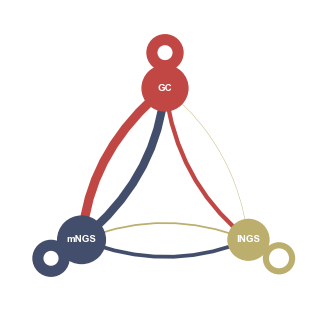

In [113]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# cu_matrix[i,j] = C_unique when target=GROUPS[i], covariate=GROUPS[j]
# Edge direction: covariate j → target i

NODE_POS = {
    'GC':   np.array([0.5,  0.82]),
    'mNGS': np.array([0.15, 0.18]),
    'lNGS': np.array([0.85, 0.18]),
}
NODE_COL = {'GC': GC_COL, 'mNGS': NGSMED_COL, 'lNGS': NGSLAT_COL}

MAX_LW = 8.0
MAX_CU = cu_matrix.max()

centroid = np.mean(list(NODE_POS.values()), axis=0)

fig, ax = plt.subplots(figsize=(4, 4))
# Extra padding so self-loops are never clipped
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.15)
ax.axis('off')

# ── Inter-node arrows ──────────────────────────────────────────────────────────
for i, tgt in enumerate(GROUPS):
    for j, cov in enumerate(GROUPS):
        val = cu_matrix[i, j]
        if val < 1e-6 or i == j:
            continue
        src = NODE_POS[cov]; dst = NODE_POS[tgt]
        lw  = MAX_LW * val / MAX_CU
        ax.annotate('', xy=dst, xytext=src,
                    arrowprops=dict(arrowstyle='->', color=NODE_COL[cov],
                                   lw=lw, connectionstyle='arc3,rad=0.2'))

# ── Self-loops ─────────────────────────────────────────────────────────────────
LOOP_R      = 0.055
LOOP_OFFSET = 0.15

for i, grp in enumerate(GROUPS):
    val = cu_matrix[i, i]
    if val < 1e-6:
        continue
    pos     = NODE_POS[grp]
    outward = pos - centroid
    outward = outward / np.linalg.norm(outward)
    loop_centre = pos + outward * LOOP_OFFSET

    circle = plt.Circle(loop_centre, LOOP_R,
                         fill=False, color=NODE_COL[grp],
                         lw=MAX_LW * val / MAX_CU, zorder=4)
    circle.set_clip_on(False)
    ax.add_patch(circle)

    # Arrowhead tangent to the circle, pointing clockwise
    perp    = np.array([-outward[1], outward[0]])   # 90° rotation
    tip     = loop_centre + perp * LOOP_R
    nudge   = perp * 0.001
    #ann = ax.annotate('', xy=tip, xytext=tip + nudge,
    #                  arrowprops=dict(arrowstyle='->', color=NODE_COL[grp],
    #                                  lw=MAX_LW * val / MAX_CU))
    #ann.arrow_patch.set_clip_on(False)

# ── Nodes ──────────────────────────────────────────────────────────────────────
for grp in GROUPS:
    pos      = NODE_POS[grp]
    total_in = cu_matrix[GROUPS.index(grp), :].sum()
    r        = 0.06 + 0.04 * total_in / cu_matrix.sum(axis=1).max()
    patch = plt.Circle(pos, r, color=NODE_COL[grp], zorder=5)
    patch.set_clip_on(False)
    ax.add_patch(patch)
    ax.text(*pos, grp, ha='center', va='center', fontsize=7,
            color='white', fontweight='bold', zorder=6)

plt.savefig(os.path.join(out_dir, 'coupling_graph.pdf'), bbox_inches='tight', dpi=300)
plt.show()


---

## Variance Decomposition: Component Calculations

All pR² values are cross-validated (10-fold). Each component is computed per (target group, covariate group) pair.

### Kinematic components — Shapley-averaged marginals at *n* = 0

Each variable has 4 valid (without, with) baseline pairs drawn from the available set. The component value is the mean marginal across all 4 routes.

| Component | Route 1 | Route 2 | Route 3 | Route 4 |
|-----------|---------|---------|---------|---------|
| **Pos** | pR²(pos,0) − pR²(null,0) | pR²(pos_speed,0) − pR²(speed,0) | pR²(pos_hd,0) − pR²(hd,0) | pR²(pos_lfp,0) − pR²(lfp,0) |
| **Speed** | pR²(speed,0) − pR²(null,0) | pR²(pos_speed,0) − pR²(pos,0) | pR²(pos_speed_hd,0) − pR²(pos_hd,0) | pR²(pos_speed_lfp,0) − pR²(pos_lfp,0) |
| **HD** | pR²(hd,0) − pR²(null,0) | pR²(pos_hd,0) − pR²(pos,0) | pR²(pos_speed_hd,0) − pR²(pos_speed,0) | pR²(pos_speed_hd_lfp,0) − pR²(pos_speed_lfp,0) |
| **LFP** | pR²(lfp,0) − pR²(null,0) | pR²(pos_lfp,0) − pR²(pos,0) | pR²(pos_speed_lfp,0) − pR²(pos_speed,0) | pR²(pos_speed_hd_lfp,0) − pR²(pos_speed_hd,0) |

*n* = 0 means zero covariate cells — these are pure kinematic baselines.

---

### Cell signal components

| Component | Formula | Interpretation |
|-----------|---------|----------------|
| **C_unique** | pR²(pos_speed_hd_lfp, *n*=MAX) − pR²(pos_speed_hd_lfp, *n*=0) | Cell gain above the *full* kinematic baseline; variance explained by cells that cannot be explained by position, speed, HD, or LFP |
| **C_shared** | [pR²(null, *n*=MAX) − pR²(null, *n*=0)] − C_unique | Total cell gain (above no kinematics) minus the unique portion; cell signal that overlaps with kinematic covariates |

---

### Notation

| Symbol | Meaning |
|--------|---------|
| pR²(bl, n) | Mean cross-validated pR² with baseline `bl` and `n` covariate cells |
| *n* = 0 | No covariate cells added (baseline only) |
| *n* = MAX | Maximum covariate cells (10) |
| pos_speed_hd_lfp | Full kinematic baseline (position, speed, head direction, LFP) |
| null | Null baseline (intercept only) |